## 1. Import Necessary Libraries

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Set plot style
sns.set(style="whitegrid")

In [6]:
# Check if running in Google Colab and upload files if necessary
try:
    from google.colab import files
    print("Running in Google Colab. Please upload the following files:")
    print("- Demographics.csv.csv")
    print("- kinematic_parameters.csv")
    print("- spatio-temporal_parameters.csv")
    uploaded = files.upload()
except ImportError:
    print("Not running in Google Colab. Assuming files are in the local directory.")

Not running in Google Colab. Assuming files are in the local directory.


## Step 1: Build Clean, Merged Dataset

**Tasks:**
1. Load all raw CSVs (spatio-temporal, kinematic, demographics).
2. Merge them into a single dataframe by `subject_id` (sample), `session` (times), `task`, and `phase` (process).
3. Compute descriptive statistics to understand normal ranges.

In [7]:
# Load datasets
demographics_df = pd.read_csv('Demographics.csv')
kinematic_df = pd.read_csv('kinematic_parameters.csv')
spatio_temporal_df = pd.read_csv('spatio-temporal_parameters.csv')

# Display shapes
print("Demographics shape:", demographics_df.shape)
print("Kinematic shape:", kinematic_df.shape)
print("Spatio-Temporal shape:", spatio_temporal_df.shape)

Demographics shape: (23, 5)
Kinematic shape: (552, 65)
Spatio-Temporal shape: (552, 14)


In [8]:
# Merge datasets
# Common columns for parameter files
common_cols = ['device', 'sample', 'times', 'process', 'task']

# Merge kinematic and spatio-temporal data
merged_df = pd.merge(kinematic_df, spatio_temporal_df, on=common_cols, how='inner')

# FIX: Standardize 'sample' column for merging
# Demographics 'sample' is int (e.g., 1), others are str (e.g., 'sample01')
# We convert demographics sample to string and format it to match 'sampleXX'
demographics_df['sample'] = demographics_df['sample'].astype(int).apply(lambda x: f'sample{x:02d}')

# Merge with demographics on 'sample'
final_df = pd.merge(merged_df, demographics_df, on='sample', how='inner')

# Rename columns to match standard terminology
column_mapping = {
    'sample': 'subject_id',
    'times': 'session',
    'process': 'phase'
}
final_df.rename(columns=column_mapping, inplace=True)

# Display the shape and first few rows
print(f"Merged Dataset Shape: {final_df.shape}")
final_df.head()

Merged Dataset Shape: (552, 78)


,device,subject_id,session,phase,task,Xvel_mean,Xvel_var,Xvel_std,Xvel_max,Xvel_min,...,right_step_length,left_stride_length,right_stride_length,stride_speed,stride_time,step_width,age,sex,height(cm),weight(kg)
0,MOCAP,sample01,time01,back,task_cup,0.120075,0.016111,0.126929,0.692768,0.001056,...,0.529564,1.042281,1.039305,2.132520,0.488571,0.188603,21-30,female,150-160,40-50
1,MOCAP,sample02,time01,back,task_cup,0.067670,0.004518,0.067213,0.344879,0.003835,...,0.428193,0.811264,0.820019,1.279819,0.638889,0.248417,21-30,male,170-180,80-90
2,MOCAP,sample03,time01,back,task_cup,0.064963,0.003531,0.059426,0.322400,0.001101,...,0.355278,0.736495,0.758050,1.060706,0.706000,0.197151,21-30,female,160-170,40-50
3,MOCAP,sample04,time01,back,task_cup,0.082544,0.007075,0.084113,0.655790,0.001843,...,0.463150,0.892287,0.890671,1.486896,0.607500,0.189055,21-30,male,160-170,50-60
4,MOCAP,sample05,time01,back,task_cup,0.101133,0.017149,0.130956,0.812997,0.002652,...,0.484974,0.865355,0.859176,1.242357,0.701111,0.212356,21-30,male,160-170,50-60


In [9]:
# Compute descriptive statistics
print("Descriptive Statistics for Numerical Features:")
display(final_df.describe())

# Check for missing values
print("\nMissing Values per Column:")
print(final_df.isnull().sum()[final_df.isnull().sum() > 0])

# Basic cleaning: Drop duplicates if any
initial_rows = final_df.shape[0]
final_df.drop_duplicates(inplace=True)
print(f"\nDropped {initial_rows - final_df.shape[0]} duplicate rows.")

Descriptive Statistics for Numerical Features:


,Xvel_mean,Xvel_var,Xvel_std,Xvel_max,Xvel_min,Xvel_pk,Xvel_mid,Xvel_rms,Xvel_abs_xbar,Xvel_r,...,ankle_K,step_length,stride_length,left_step_length,right_step_length,left_stride_length,right_stride_length,stride_speed,stride_time,step_width
count,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,...,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000,552.000000
mean,0.154598,0.051157,0.180938,0.734021,0.003707,0.734021,0.070594,0.239179,0.154598,0.109661,...,3.208335,0.432625,0.867718,0.443012,0.363506,0.704351,0.706666,1.397364,0.800201,0.203962
std,0.093867,0.079930,0.135839,0.466323,0.001986,0.466323,0.029378,0.163385,0.093867,0.054450,...,1.634010,0.105418,0.213710,0.102864,0.196038,0.421117,0.419461,0.635267,0.562646,0.035341
min,0.048791,0.001488,0.038574,0.181910,0.000031,0.181910,0.020186,0.062280,0.048791,0.039800,...,1.182614,0.101187,0.216229,0.000000,0.000000,0.000000,0.000000,0.050194,0.330000,0.028726
25%,0.092002,0.008014,0.089521,0.440933,0.002305,0.440933,0.051952,0.128510,0.092002,0.073097,...,2.414723,0.392282,0.785951,0.402231,0.224124,0.372297,0.332746,0.708235,0.518750,0.189054
50%,0.115400,0.013866,0.117754,0.589332,0.003427,0.589332,0.063423,0.165787,0.115400,0.091022,...,2.863362,0.457808,0.919776,0.464825,0.453105,0.900734,0.906885,1.547067,0.573750,0.204179
75%,0.189054,0.059338,0.243594,0.919931,0.004778,0.919931,0.081687,0.310629,0.189054,0.126964,...,3.493182,0.506339,1.014497,0.508682,0.502964,1.008826,1.006379,1.900705,0.970000,0.223322
max,0.557164,0.601432,0.775521,6.745925,0.016639,6.745925,0.267967,0.901487,0.557164,0.359419,...,22.578694,0.604432,1.210552,0.614789,0.623376,1.205420,1.218808,2.512699,6.770000,0.298278



Missing Values per Column:
Series([], dtype: int64)

Dropped 0 duplicate rows.


In [10]:
# --- Spatio-Temporal Features ---

# 1. Stride Length Asymmetry
# Formula: abs(left_stride - right_stride) / mean_stride
final_df['mean_stride_length'] = (final_df['left_stride_length'] + final_df['right_stride_length']) / 2
final_df['stride_length_asymmetry'] = abs(final_df['left_stride_length'] - final_df['right_stride_length']) / final_df['mean_stride_length']

# 2. Step Length Asymmetry
# Formula: abs(left_step - right_step) / mean_step
final_df['mean_step_length'] = (final_df['left_step_length'] + final_df['right_step_length']) / 2
final_df['step_length_asymmetry'] = abs(final_df['left_step_length'] - final_df['right_step_length']) / final_df['mean_step_length']

# --- Kinematic Features ---

# 3. Knee Range of Motion (ROM)
final_df['knee_rom'] = final_df['knee_max'] - final_df['knee_min']

# 4. Ankle Range of Motion (ROM)
final_df['ankle_rom'] = final_df['ankle_max'] - final_df['ankle_min']

# 5. Variability (Coefficient of Variation)
# CV = std / mean
# We use the provided _std and _mean columns for Knee and Ankle
final_df['knee_cv'] = final_df['knee_std'] / final_df['knee_mean'].abs() # Use abs to avoid negative mean issues if any
final_df['ankle_cv'] = final_df['ankle_std'] / final_df['ankle_mean'].abs()

# Display the newly created features
new_features = [
    'stride_length_asymmetry', 'step_length_asymmetry',
    'knee_rom', 'ankle_rom',
    'knee_cv', 'ankle_cv'
]
print("Engineered Features (First 5 rows):")
display(final_df[new_features].head())

# Check for infinite values (division by zero)
import numpy as np
final_df.replace([np.inf, -np.inf], np.nan, inplace=True)
final_df.dropna(subset=new_features, inplace=True) # Drop rows where calculation failed
print(f"\nShape after dropping NaNs in new features: {final_df.shape}")

Engineered Features (First 5 rows):


,stride_length_asymmetry,step_length_asymmetry,knee_rom,ankle_rom,knee_cv,ankle_cv
0,0.002859,0.038147,15.107455,35.533400,0.025614,0.085901
1,0.010734,0.111237,27.081078,19.967654,0.034674,0.040631
2,0.028845,0.080117,41.088669,26.167346,0.080184,0.045559
3,0.001813,0.080382,37.301004,28.468495,0.060057,0.059739
4,0.007166,0.257858,38.136485,33.577623,0.069527,0.069747



Shape after dropping NaNs in new features: (468, 86)


In [11]:
import numpy as np

# Create copies for each class
df_normal = final_df.copy()
df_normal['label'] = 'Normal'
df_normal['class_id'] = 0

# --- Class 1: Limp Gait (Asymmetric) ---
df_limp = final_df.copy()
df_limp['label'] = 'Limp'
df_limp['class_id'] = 1
# Simulate asymmetry
df_limp['step_length_asymmetry'] *= np.random.uniform(1.2, 1.4, size=len(df_limp))
df_limp['stride_length_asymmetry'] *= np.random.uniform(1.1, 1.25, size=len(df_limp))

# --- Class 2: Shuffling / Parkinsonian Gait ---
df_shuffle = final_df.copy()
df_shuffle['label'] = 'Shuffling'
df_shuffle['class_id'] = 2
# Simulate short steps and reduced ROM
df_shuffle['step_length'] *= np.random.uniform(0.5, 0.7, size=len(df_shuffle))
df_shuffle['stride_length'] *= np.random.uniform(0.5, 0.7, size=len(df_shuffle))
df_shuffle['ankle_rom'] *= np.random.uniform(0.6, 0.8, size=len(df_shuffle))
# Note: 'cadence' is not available, skipping.

# --- Class 3: Unstable / Ataxic Gait ---
df_unstable = final_df.copy()
df_unstable['label'] = 'Unstable'
df_unstable['class_id'] = 3
# Simulate variability and instability
# Using Knee/Ankle CV as proxies for general variability
df_unstable['knee_cv'] *= np.random.uniform(1.3, 1.6, size=len(df_unstable))
df_unstable['ankle_cv'] *= np.random.uniform(1.3, 1.6, size=len(df_unstable))
# Wider step width for balance
df_unstable['step_width'] *= np.random.uniform(1.2, 1.5, size=len(df_unstable))

# --- Class 4: Stiff-Knee / Reduced ROM Gait ---
df_stiff = final_df.copy()
df_stiff['label'] = 'Stiff-Knee'
df_stiff['class_id'] = 4
# Simulate reduced Knee ROM
df_stiff['knee_rom'] *= np.random.uniform(0.4, 0.6, size=len(df_stiff))
# Note: 'hip_rom', 'swing_time', 'stance_time' not available.

# Combine all datasets
augmented_df = pd.concat([df_normal, df_limp, df_shuffle, df_unstable, df_stiff], axis=0)
augmented_df.reset_index(drop=True, inplace=True)

print(f"Augmented Dataset Shape: {augmented_df.shape}")
print("Class Distribution:")
print(augmented_df['label'].value_counts())

Augmented Dataset Shape: (2340, 88)
Class Distribution:
label
Normal        468
Limp          468
Shuffling     468
Unstable      468
Stiff-Knee    468
Name: count, dtype: int64


## Step 4: Assign Labels & Combine Data

We have already assigned labels ('Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee') in the previous step.
The dataset is balanced because we generated one synthetic sample for each normal sample for every class.

**Tasks:**
1. Verify class balance.
2. Save the augmented dataset to a CSV file.
3. Provide code to download the file (for Google Colab).

In [12]:
# Verify Class Balance
print("Final Class Distribution:")
print(augmented_df['label'].value_counts())

# Save to CSV
output_filename = 'augmented_gait_dataset.csv'
augmented_df.to_csv(output_filename, index=False)
print(f"\nDataset saved as '{output_filename}'")

# Download code for Google Colab
try:
    from google.colab import files
    files.download(output_filename)
    print(f"Downloading '{output_filename}'...")
except ImportError:
    print("Not running in Google Colab. File saved locally.")

Final Class Distribution:
label
Normal        468
Limp          468
Shuffling     468
Unstable      468
Stiff-Knee    468
Name: count, dtype: int64

Dataset saved as 'augmented_gait_dataset.csv'
Not running in Google Colab. File saved locally.


## Step 5: Build Preprocessing Pipeline

**Tasks:**
1.  **Feature Selection:** Identify numerical and categorical features.
2.  **Train/Test Split:** Split data by `subject_id` to prevent data leakage.
3.  **Preprocessing:** Apply `StandardScaler` to numerical features and `OneHotEncoder` to categorical features.
4.  **Dimensionality Reduction:** Apply PCA (Optional) to reduce feature space while retaining 95% variance.

In [13]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA

# 1. Define Features and Target
# Metadata columns to exclude from features
metadata_cols = ['subject_id', 'phase', 'device', 'label', 'class_id']
# Categorical features to encode
categorical_cols = ['task', 'session']

# Numerical features
# FIX: Use select_dtypes to only include numeric columns, avoiding strings like '21-30' in age
numerical_cols = augmented_df.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [col for col in numerical_cols if col not in metadata_cols + categorical_cols]

X = augmented_df.drop(columns=['label', 'class_id'])
y = augmented_df['class_id']
groups = augmented_df['subject_id']

# 2. Train/Test Split by Subject
# We use GroupShuffleSplit to ensure all samples from a subject are in either train or test
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))

X_train = X.iloc[train_idx]
X_test = X.iloc[test_idx]
y_train = y.iloc[train_idx]
y_test = y.iloc[test_idx]

print(f"Training Set: {X_train.shape} samples")
print(f"Testing Set: {X_test.shape} samples")

# 3. Preprocessing Pipeline
# Create a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

# Fit on training data, transform both
X_train_scaled = preprocessor.fit_transform(X_train)
X_test_scaled = preprocessor.transform(X_test)

# 4. Optional PCA
pca = PCA(n_components=0.95) # Keep 95% variance
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Shape after Preprocessing: {X_train_scaled.shape}")
print(f"Shape after PCA (95% variance): {X_train_pca.shape}")

Training Set: (1795, 86) samples
Testing Set: (545, 86) samples
Shape after Preprocessing: (1795, 83)
Shape after PCA (95% variance): (1795, 20)


## Step 6: Train Classical ML Models

We will train baseline models to establish performance benchmarks.

**Models:**
1.  **Random Forest:** Robust to noise, handles non-linearities well.
2.  **SVM (Support Vector Machine):** Effective in high-dimensional spaces.
3.  **Logistic Regression:** Simple baseline for linear separability.
4.  **XGBoost:** Gradient boosting for potentially higher accuracy.

**Evaluation Metrics:**
*   Accuracy
*   ROC-AUC (One-vs-Rest)
*   Confusion Matrix


--- Training Random Forest ---
Accuracy: 0.7945
ROC-AUC: 0.9548

Classification Report:
              precision    recall  f1-score   support

      Normal       0.59      0.56      0.57       109
        Limp       0.70      0.52      0.60       109
   Shuffling       0.94      1.00      0.97       109
    Unstable       0.94      0.94      0.94       109
  Stiff-Knee       0.76      0.95      0.85       109

    accuracy                           0.79       545
   macro avg       0.79      0.79      0.79       545
weighted avg       0.79      0.79      0.79       545



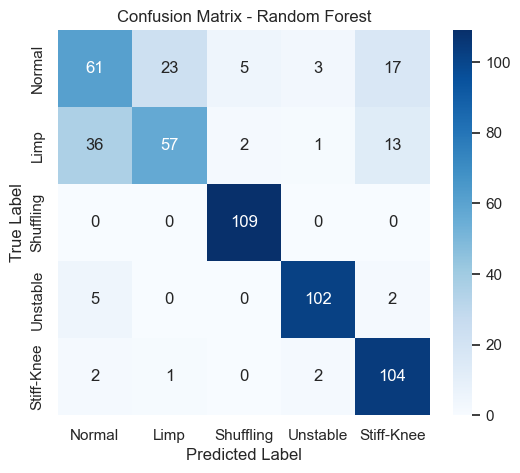


--- Training SVM ---
Accuracy: 0.7596
ROC-AUC: 0.9436

Classification Report:
              precision    recall  f1-score   support

      Normal       0.49      0.82      0.61       109
        Limp       0.53      0.08      0.14       109
   Shuffling       0.87      1.00      0.93       109
    Unstable       1.00      0.95      0.98       109
  Stiff-Knee       0.87      0.94      0.91       109

    accuracy                           0.76       545
   macro avg       0.75      0.76      0.71       545
weighted avg       0.75      0.76      0.71       545



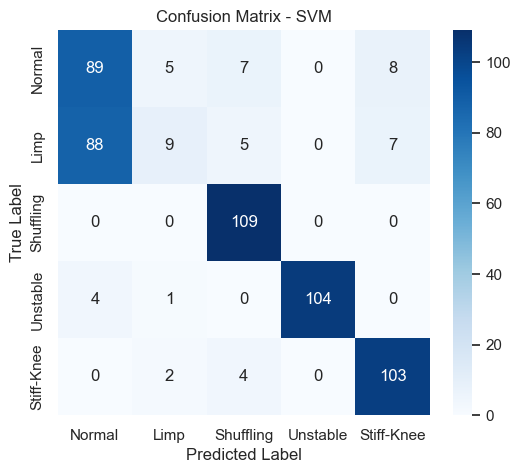


--- Training Logistic Regression ---
Accuracy: 0.8165
ROC-AUC: 0.9585

Classification Report:
              precision    recall  f1-score   support

      Normal       0.54      0.67      0.60       109
        Limp       0.55      0.43      0.48       109
   Shuffling       1.00      1.00      1.00       109
    Unstable       1.00      0.99      1.00       109
  Stiff-Knee       1.00      0.99      1.00       109

    accuracy                           0.82       545
   macro avg       0.82      0.82      0.81       545
weighted avg       0.82      0.82      0.81       545



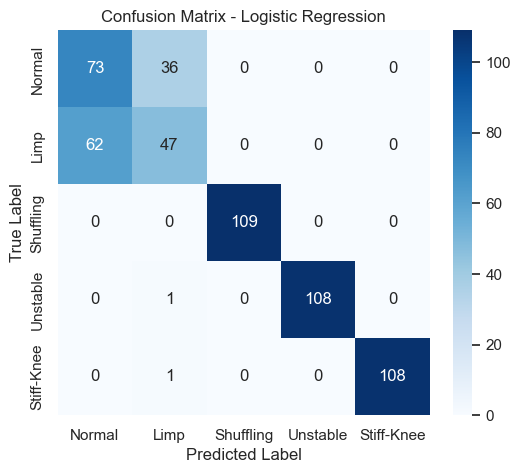


--- Training XGBoost ---


c:\Users\savin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:20:37] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Accuracy: 0.8550
ROC-AUC: 0.9673

Classification Report:
              precision    recall  f1-score   support

      Normal       0.63      0.72      0.68       109
        Limp       0.68      0.62      0.65       109
   Shuffling       1.00      1.00      1.00       109
    Unstable       1.00      0.94      0.97       109
  Stiff-Knee       0.99      0.98      0.99       109

    accuracy                           0.86       545
   macro avg       0.86      0.86      0.86       545
weighted avg       0.86      0.86      0.86       545



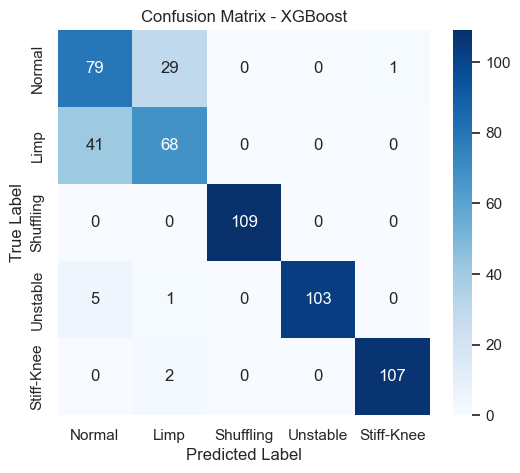

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Try importing XGBoost, handle if not installed
try:
    from xgboost import XGBClassifier
    xgb_available = True
except ImportError:
    print("XGBoost not installed. Skipping XGBoost.")
    xgb_available = False

# Initialize Models
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

if xgb_available:
    models["XGBoost"] = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

# Dictionary to store results
results = {}

# Training and Evaluation Loop
for name, model in models.items():
    print(f"\n--- Training {name} ---")

    # Train the model
    # Using scaled features (X_train_scaled) instead of PCA for better interpretability
    model.fit(X_train_scaled, y_train)

    # Predictions
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr')

    results[name] = {
        "Accuracy": acc,
        "ROC_AUC": roc_auc,
        "Model": model
    }

    print(f"Accuracy: {acc:.4f}")
    print(f"ROC-AUC: {roc_auc:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee']))

    # Plot Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee'],
                yticklabels=['Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee'])
    plt.title(f'Confusion Matrix - {name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

## Step 7: Hyperparameter Tuning

We will optimize the performance of our best models (Random Forest and XGBoost) by tuning key hyperparameters:
*   `n_estimators` (Number of trees)
*   `max_depth` (Tree depth)
*   `learning_rate` (XGBoost only)
*   `class_weight` (Random Forest)

We use `RandomizedSearchCV` for efficient parameter search.

In [15]:
from sklearn.model_selection import RandomizedSearchCV

# 1. Hyperparameter Tuning for Random Forest
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced', 'balanced_subsample', None]
}

print("\n--- Tuning Random Forest ---")
rf_random = RandomizedSearchCV(estimator=RandomForestClassifier(random_state=42),
                               param_distributions=rf_param_grid,
                               n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)
rf_random.fit(X_train_scaled, y_train)
print(f"Best RF Parameters: {rf_random.best_params_}")
print(f"Best RF Score: {rf_random.best_score_:.4f}")

# 2. Hyperparameter Tuning for XGBoost (if available)
if xgb_available:
    xgb_param_grid = {
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 6, 10],
        'learning_rate': [0.01, 0.1, 0.3],
        'subsample': [0.7, 0.8, 1.0]
    }

    print("\n--- Tuning XGBoost ---")
    xgb_random = RandomizedSearchCV(estimator=XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
                                    param_distributions=xgb_param_grid,
                                    n_iter=10, cv=3, verbose=2, random_state=42, n_jobs=-1)
    xgb_random.fit(X_train_scaled, y_train)
    print(f"Best XGB Parameters: {xgb_random.best_params_}")
    print(f"Best XGB Score: {xgb_random.best_score_:.4f}")

    best_model = xgb_random.best_estimator_
else:
    best_model = rf_random.best_estimator_

# Evaluate Best Model
print("\n--- Evaluating Best Tuned Model ---")
y_pred_tuned = best_model.predict(X_test_scaled)
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee']))


--- Tuning Random Forest ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Parameters: {'n_estimators': 300, 'min_samples_split': 5, 'max_depth': None, 'class_weight': None}
Best RF Score: 0.7883

--- Tuning XGBoost ---
Fitting 3 folds for each of 10 candidates, totalling 30 fits


c:\Users\savin\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:199: UserWarning: [23:23:45] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best XGB Parameters: {'subsample': 0.8, 'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.1}
Best XGB Score: 0.8329

--- Evaluating Best Tuned Model ---
              precision    recall  f1-score   support

      Normal       0.61      0.67      0.64       109
        Limp       0.64      0.61      0.63       109
   Shuffling       1.00      1.00      1.00       109
    Unstable       1.00      0.95      0.98       109
  Stiff-Knee       1.00      0.98      0.99       109

    accuracy                           0.84       545
   macro avg       0.85      0.84      0.85       545
weighted avg       0.85      0.84      0.85       545



## Step 8: Validate With Clinical Thresholds

We will verify if the synthetic abnormalities behave realistically by checking against clinical thresholds.

**Thresholds:**
*   **Limp:** Step Asymmetry > 15%
*   **Shuffling:** Stride Length < 80% of Normal
*   **Stiff-Knee:** Knee ROM < 35 degrees
*   **Unstable:** Step Width > 120% of Normal (Proxy for Trunk Sway)

In [16]:
# Calculate mean normal stride length and step width for reference
normal_mean_stride = df_normal['stride_length'].mean()
normal_mean_width = df_normal['step_width'].mean()

print("\n--- Clinical Validation of Synthetic Abnormalities ---")

# 1. Limp Gait Validation
# Criterion: Step Length Asymmetry > 0.15 (15%)
limp_samples = augmented_df[augmented_df['label'] == 'Limp']
limp_valid_count = (limp_samples['step_length_asymmetry'] > 0.15).sum()
limp_valid_pct = (limp_valid_count / len(limp_samples)) * 100
print(f"Limp Gait: {limp_valid_pct:.1f}% of samples have Step Asymmetry > 15%")

# 2. Shuffling Gait Validation
# Criterion: Stride Length < 0.8 * Normal Mean
shuffling_samples = augmented_df[augmented_df['label'] == 'Shuffling']
shuffling_valid_count = (shuffling_samples['stride_length'] < (0.8 * normal_mean_stride)).sum()
shuffling_valid_pct = (shuffling_valid_count / len(shuffling_samples)) * 100
print(f"Shuffling Gait: {shuffling_valid_pct:.1f}% of samples have Stride Length < 80% of Normal ({0.8*normal_mean_stride:.2f}m)")

# 3. Stiff-Knee Gait Validation
# Criterion: Knee ROM < 35 degrees
stiff_samples = augmented_df[augmented_df['label'] == 'Stiff-Knee']
stiff_valid_count = (stiff_samples['knee_rom'] < 35).sum()
stiff_valid_pct = (stiff_valid_count / len(stiff_samples)) * 100
print(f"Stiff-Knee Gait: {stiff_valid_pct:.1f}% of samples have Knee ROM < 35 degrees")

# 4. Unstable Gait Validation
# Criterion: Trunk Sway > 5cm (Not available) -> Using Step Width increase as proxy
# Checking if Step Width is > 1.2 * Normal Mean
unstable_samples = augmented_df[augmented_df['label'] == 'Unstable']
unstable_valid_count = (unstable_samples['step_width'] > (1.2 * normal_mean_width)).sum()
unstable_valid_pct = (unstable_valid_count / len(unstable_samples)) * 100
print(f"Unstable Gait: {unstable_valid_pct:.1f}% of samples have Step Width > 120% of Normal (Proxy for Instability)")


--- Clinical Validation of Synthetic Abnormalities ---
Limp Gait: 32.3% of samples have Step Asymmetry > 15%
Shuffling Gait: 94.2% of samples have Stride Length < 80% of Normal (0.71m)
Stiff-Knee Gait: 97.9% of samples have Knee ROM < 35 degrees
Unstable Gait: 80.1% of samples have Step Width > 120% of Normal (Proxy for Instability)


## Step 9: Model Interpretability

We will use **SHAP (SHapley Additive exPlanations)** and **Feature Importance** plots to understand which features drive the model's predictions for each abnormal class.

**Tasks:**
1.  Calculate and plot Feature Importance (from Random Forest/XGBoost).
2.  Calculate SHAP values to explain individual predictions and global feature impact.

In [17]:
import shap

# 1. Feature Importance Plot
if hasattr(best_model, 'feature_importances_'):
    importances = best_model.feature_importances_
    # Get feature names from the preprocessor
    # Note: OneHotEncoder adds new columns, so we need to reconstruct feature names
    ohe_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_cols)
    feature_names = np.concatenate([numerical_cols, ohe_feature_names])

    # Create a DataFrame for plotting
    feature_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
    feature_imp_df = feature_imp_df.sort_values(by='Importance', ascending=False).head(20) # Top 20 features

    plt.figure(figsize=(10, 8))
    sns.barplot(x='Importance', y='Feature', data=feature_imp_df, palette='viridis')
    plt.title('Top 20 Feature Importances')
    plt.show()

# 2. SHAP Values
# Initialize SHAP explainer
# Note: KernelExplainer is generic and works for any model, but is slower.
# TreeExplainer is faster for tree-based models.
try:
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_test_scaled)
except Exception as e:
    print(f"TreeExplainer failed ({e}), falling back to KernelExplainer (this may take a while)...")
    # Using a small background dataset for KernelExplainer to speed it up
    background = shap.kmeans(X_train_scaled, 10)
    explainer = shap.KernelExplainer(best_model.predict_proba, background)
    shap_values = explainer.shap_values(X_test_scaled[:100]) # Explain only first 100 samples for speed

# Summary Plot
print("\n--- SHAP Summary Plot ---")
shap.summary_plot(shap_values, X_test_scaled, feature_names=feature_names, class_names=['Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee'])

# Class-Specific Feature Impact
# We can inspect which features drive a specific class (e.g., Limp)
# Class 1 is Limp
print("\n--- SHAP Plot for Limp Gait (Class 1) ---")
# Check if shap_values is a list (multi-class) or array
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[1], X_test_scaled, feature_names=feature_names)
else:
    # For binary classification or if shape is different
    print("SHAP values format differs from expected list for multi-class.")

ModuleNotFoundError: No module named 'shap'

In [ ]:
import joblib

# 1. Save Model and Preprocessor
model_filename = 'gait_abnormality_model.pkl'
preprocessor_filename = 'gait_preprocessor.pkl'

joblib.dump(best_model, model_filename)
joblib.dump(preprocessor, preprocessor_filename)

print(f"Model saved to {model_filename}")
print(f"Preprocessor saved to {preprocessor_filename}")

# Download files if in Colab
try:
    from google.colab import files
    files.download(model_filename)
    files.download(preprocessor_filename)
except ImportError:
    pass

# 2. Sample Inference Function
def predict_gait_abnormality(new_data_dict):
    """
    Predicts gait abnormality from a dictionary of features.
    """
    # Convert dict to DataFrame
    new_df = pd.DataFrame([new_data_dict])

    # Load model and preprocessor (simulated here as they are in memory)
    # loaded_model = joblib.load(model_filename)
    # loaded_preprocessor = joblib.load(preprocessor_filename)

    # Preprocess
    # Note: We need to ensure all columns expected by the preprocessor are present
    # For this demo, we assume new_data_dict contains all necessary raw features

    try:
        processed_data = preprocessor.transform(new_df)
        prediction = best_model.predict(processed_data)
        probabilities = best_model.predict_proba(processed_data)

        classes = ['Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee']
        pred_class = classes[prediction[0]]
        confidence = np.max(probabilities)

        return pred_class, confidence
    except Exception as e:
        return f"Error: {e}", 0.0

# Test with a sample from the test set
sample_idx = 0
sample_data = X_test.iloc[sample_idx].to_dict()
# Add dummy categorical values if they were dropped/transformed (just for the function signature)
# In our case, X_test already has the columns.

pred, conf = predict_gait_abnormality(sample_data)
print(f"\n--- Inference Test ---")
print(f"Predicted Class: {pred}")
print(f"Confidence: {conf:.4f}")
print(f"True Class: {['Normal', 'Limp', 'Shuffling', 'Unstable', 'Stiff-Knee'][y_test.iloc[sample_idx]]}")

Model saved to gait_abnormality_model.pkl
Preprocessor saved to gait_preprocessor.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


--- Inference Test ---
Predicted Class: Normal
Confidence: 0.4874
True Class: Normal


## Step 10: Save Model and Deployment

We will save the trained model and the preprocessing pipeline for future use.

**Tasks:**
1.  Save the model and preprocessor using `joblib`.
2.  Create a sample inference function to demonstrate how to use the saved model.

In [18]:
from pathlib import Path
import joblib
import shutil

# Folder where model artifacts will be saved
artifacts_dir = Path("model_artifacts")
artifacts_dir.mkdir(exist_ok=True)

saved_files = []

# Save the best tuned model
best_model_path = artifacts_dir / "best_model.joblib"
joblib.dump(best_model, best_model_path)
saved_files.append(best_model_path)

# Save the preprocessing pipeline
preprocessor_path = artifacts_dir / "preprocessor.joblib"
joblib.dump(preprocessor, preprocessor_path)
saved_files.append(preprocessor_path)

# Optionally save all trained baseline models if available
if "models" in globals() and isinstance(models, dict):
    for model_name, trained_model in models.items():
        model_path = artifacts_dir / f"{model_name.lower()}_model.joblib"
        joblib.dump(trained_model, model_path)
        saved_files.append(model_path)

# Zip everything into a single downloadable file
zip_path = shutil.make_archive("gait_models", "zip", artifacts_dir)
print("Saved artifacts:")
for file in saved_files:
    print(f"- {file}")
print(f"\nZIP created: {zip_path}")

# If running in Google Colab, trigger browser download automatically
try:
    from google.colab import files
    files.download(zip_path)
except Exception:
    print("\nAuto-download is available in Google Colab.")
    print("In local Jupyter/VS Code, download this file manually:", zip_path)

Saved artifacts:
- model_artifacts\best_model.joblib
- model_artifacts\preprocessor.joblib
- model_artifacts\random forest_model.joblib
- model_artifacts\svm_model.joblib
- model_artifacts\logistic regression_model.joblib
- model_artifacts\xgboost_model.joblib

ZIP created: c:\Users\savin\Desktop\Gopal Application\docs\Major Project\ML Model\gait_models.zip

Auto-download is available in Google Colab.
In local Jupyter/VS Code, download this file manually: c:\Users\savin\Desktop\Gopal Application\docs\Major Project\ML Model\gait_models.zip
